In [1]:
import os
import sys
import polars as pl
from pathlib import Path

# examples 폴더에서 실행 중인 경우에만 부모로 이동
current_dir = Path.cwd()
if current_dir.name == 'examples':
    project_root = current_dir.parent
else:
    project_root = current_dir

# Python 경로에 추가 및 작업 디렉토리 변경
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from packages.ABTest.BinaryTest import two_group_proportion_test

print(f"현재 작업 디렉토리: {os.getcwd()}")

현재 작업 디렉토리: d:\Github\DataAnalyticsTools\DataAnalyticsTools


### 기본 데이터 불러오기


In [2]:
DATA_PATH_LOGIT = './shared/ab_test_example_data/logistic_dataset.csv'
DATA_PATH_NORM = './shared/ab_test_example_data/normal_dataset.csv'
DATA_PATH_GAMMA = './shared/ab_test_example_data/gamma_dataset.csv'

### 범주형 데이터 (비율 데이터 -> 클릭, 전환 등)의 A/B 테스트

- 두 집단에 대한 A/B 테스트를 수행합니다
- 양측 검정, 단측 검정 중 하나를 수행할 수 있습니다
- 단측 검정의 경우, smaller / larger를 설정해야만 합니다

데이터의 형상은 다음과 같아야합니다. 아래는 실험을 위한 데이터의 형상과 출력 결과를 나타냅니다

In [5]:
data = pl.read_csv(DATA_PATH_LOGIT)
data.head(2)

group,is_purchase
str,i64
"""B""",1
"""B""",0



          Two-Proportion Z-Test가 수행되었습니다
            ------------------------------------------------
            이표본 양측 비율 검정 결과
            ------------------------------------------------
            유의수준 α = 0.05   신뢰수준 = 95.0%

            그룹 A: A (n=700, x=302, p=0.4314 95.0% CI: 0.3947 ~ 0.4681)
            그룹 B: B (n=800, x=270, p=0.3375 95.0% CI: 0.3047 ~ 0.3703)
            * 신뢰구간은 Wald score interval 방법으로 계산 되었습니다
            ------------------------------------------------
            H0: p(A) = p(B)
            H1: p(A) ≠ p(B)
            diff : 0.0939 (95.0% CI: 0.0447 ~ 0.1431) | p-value = 0.00019
            결론: 귀무가설 기각
            ------------------------------------------------
          


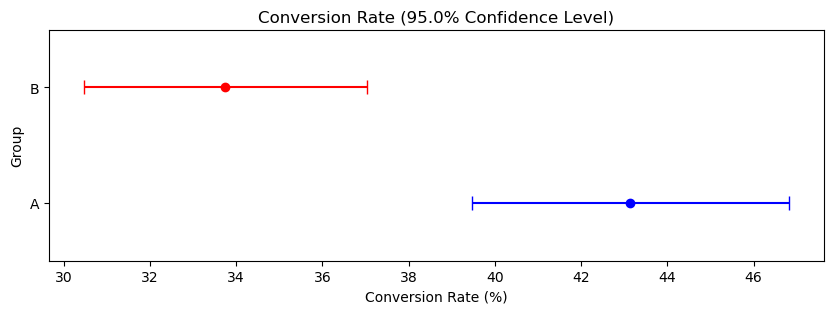

{'z': 3.7365031926316647,
 'p_value': 0.00018659708095000168,
 'label_a': 'A',
 'pa': 0.43142857142857144,
 'label_b': 'B',
 'pb': 0.3375,
 'ci_a': (0.3947387127868551, 0.4681184300702878),
 'ci_b': (0.3047332832131907, 0.37026671678680934)}

In [6]:
two_group_proportion_test(data,
                          group_col='group',
                          target_col='is_purchase',
                          alpha=0.05,
                          alternative='two-sided')

In [ ]:
two_group_proportion_test(data,
                          group_col='group',
                          target_col='is_purchase',
                          alpha=0.05,
                          alternative='smaller')